Data Sample:
   records  Feature 1  Feature 2  Feature 3  Feature 4
0        1        5.1        3.5        1.4        0.2
1        2        4.9        3.0        1.4        0.2
2        3        4.7        3.2        1.3        0.2
3        4        4.6        3.1        1.5        0.2
4        5        5.0        3.6        1.4        0.2
Final centroids for K=2: [[112.5          6.34605263   2.90394737   5.09342105   1.78026316]
 [ 37.5          5.32702703   3.21486486   2.38648649   0.6027027 ]]
Cluster assignments: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
Sum of Squared Errors (SSE): 70649.59027738265
SSE for different initializations: [70649.59027738265, 70649.59027738265, 70649.59027738265, 70649.59027738265, 70649.590

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


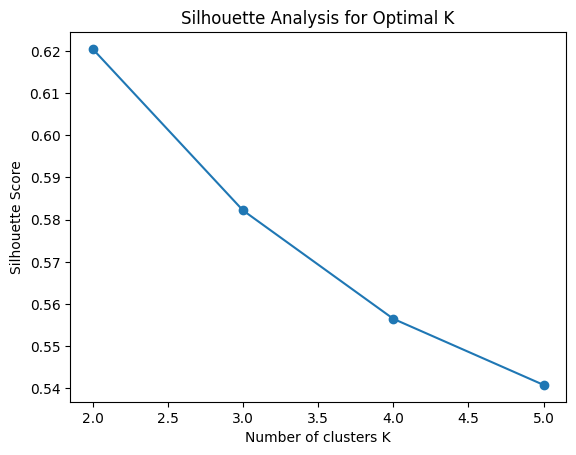

Optimal K based on Silhouette Score: 2


/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


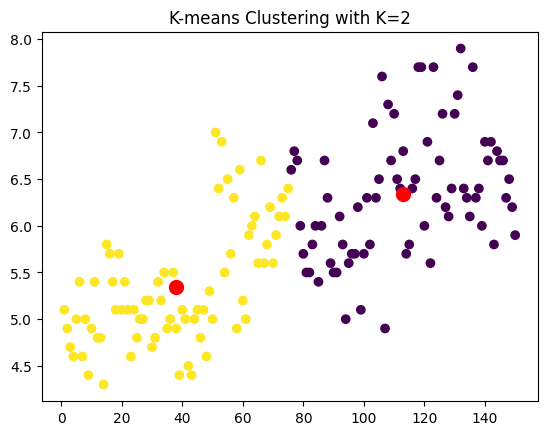

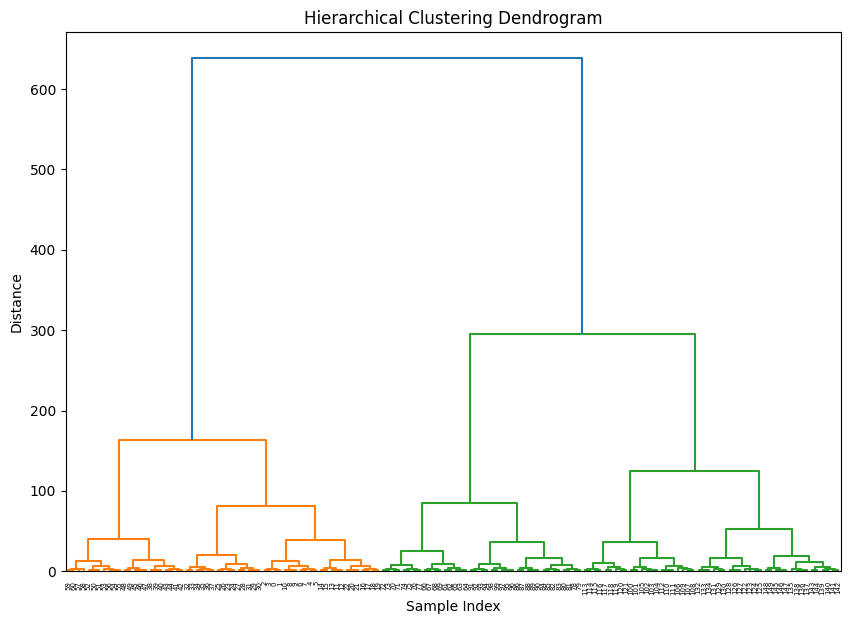

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the data
file_path = 'Assignment6_data.xlsx'  # Make sure this file is in the same directory
data = pd.read_excel('/kaggle/input/assignment6-data/Assignment6_data.xlsx')

# Inspect the data to ensure it loaded correctly
print("Data Sample:")
print(data.head())

# Convert data to numpy array for clustering if necessary
data_values = data.values

# --- Problem 1: K-means with K=2 ---
def kmeans_custom(data, K=2, max_iterations=100):
    # Initialize centroids randomly
    np.random.seed(42)  # For reproducibility
    centroids = data[np.random.choice(data.shape[0], K, replace=False)]
    
    for i in range(max_iterations):
        # Step 1: Assign clusters
        distances = np.sqrt(((data - centroids[:, np.newaxis])**2).sum(axis=2))
        clusters = np.argmin(distances, axis=0)
        
        # Step 2: Recompute centroids
        new_centroids = np.array([data[clusters == k].mean(axis=0) for k in range(K)])
        
        # Check for convergence
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    # Calculate SSE
    sse = sum(np.min(distances, axis=0)**2)
    return centroids, clusters, sse

centroids, clusters, sse = kmeans_custom(data_values, K=2)
print("Final centroids for K=2:", centroids)
print("Cluster assignments:", clusters)
print("Sum of Squared Errors (SSE):", sse)

# --- Problem 2: Different Initializations for K-means ---
initializations = 5
sse_results = []
for i in range(initializations):
    centroids, clusters, sse = kmeans_custom(data_values, K=2)
    sse_results.append(sse)
print("SSE for different initializations:", sse_results)

# --- Problem 3: Optimal K using Silhouette Score ---
K_range = [2, 3, 4, 5]
silhouette_scores = []
for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42)
    cluster_labels = kmeans.fit_predict(data_values)
    silhouette_avg = silhouette_score(data_values, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Scores
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal K")
plt.show()

# Choose optimal K based on silhouette scores
optimal_K = K_range[np.argmax(silhouette_scores)]
print("Optimal K based on Silhouette Score:", optimal_K)

# Apply K-means with optimal K and plot results
kmeans = KMeans(n_clusters=optimal_K, random_state=42)
clusters = kmeans.fit_predict(data_values)
plt.scatter(data_values[:, 0], data_values[:, 1], c=clusters, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red')
plt.title(f"K-means Clustering with K={optimal_K}")
plt.show()

# --- Problem 4: Hierarchical Clustering and Dendrogram ---
# Perform hierarchical clustering
Z = linkage(data_values, method='ward', metric='euclidean')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()
